# Описание данных

Данные - специально подготовленная выборка из полного набора, описанного здесь: https://mengtingwan.github.io/data/goodreads#datasets с дополнениями из https://www.kaggle.com/datasets/austinreese/goodreads-books:
- books: перечень книг (~44 тыс.) из списка https://www.goodreads.com/list/show/1.Best_Books_Ever (совпадение по book id),
- interactions: взаимодействие пользователей с книгами

Основной массив данных был собран в конце 2017.

# Инициализация

In [31]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [32]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

Создаём логгер, который удобен для использования в ноутбуке.

# Load Data

Загружаем данные как они есть, начинаем на них смотреть: какие в них есть сущности, атрибуты, распределения.

In [33]:
books = pd.read_parquet("./goodsread/books.parquet")

In [34]:
books.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43312 entries, 3 to 2360448
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   book_id               43312 non-null  int64  
 1   author                43312 non-null  object 
 2   title                 43312 non-null  object 
 3   description           43312 non-null  object 
 4   genre_and_votes       43312 non-null  object 
 5   num_pages             37001 non-null  Int64  
 6   average_rating        43312 non-null  float64
 7   ratings_count         43312 non-null  Int64  
 8   text_reviews_count    43312 non-null  int64  
 9   publisher             43312 non-null  object 
 10  publication_year      35891 non-null  Int64  
 11  country_code          43312 non-null  object 
 12  language_code         43312 non-null  object 
 13  format                43312 non-null  object 
 14  is_ebook              43312 non-null  bool   
 15  isbn                  

Пример данных по книгам

In [35]:
print(books[["book_id", "author", "title", "num_pages", "average_rating"]].sample(5, random_state=52).sort_values("book_id").set_index("book_id").to_string())

                                             author                                            title  num_pages  average_rating
book_id                                                                                                                        
69882                 Heinrich Böll, Patrick Bowles                      Billiards at Half-Past Nine        288            3.93
267533                               Robert Cormier                                         8 Plus 1        173            3.67
820966    Martin Luther, J.I. Packer, O.R. Johnston                          The Bondage of the Will        322            4.17
4532622                               Karen Hancock                                      The Enclave        492            3.82
20444381                             Diana Gabaldon  Os tambores de outono - 1ª Parte (Outlander #4)       1048            3.99


In [36]:
interactions = pd.read_parquet("./goodsread/interactions.parquet")

Можно оценить объём данных о взаимодействиях

In [37]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12890434 entries, 0 to 12914458
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   user_id      object
 1   book_id      int64 
 2   started_at   object
 3   read_at      object
 4   is_read      bool  
 5   rating       int64 
 6   is_reviewed  bool  
dtypes: bool(2), int64(2), object(3)
memory usage: 614.7+ MB


Пример данных по взаимодействиям

In [38]:
print(interactions[["user_id", "book_id", "started_at", "read_at", "is_read", "rating"]].sample(5, random_state=52).sort_values("user_id").set_index(["user_id", "book_id"]).to_string())

                                           started_at     read_at  is_read  rating
user_id                          book_id                                          
0447747f44c0d8d1a08cf329fe253f29 10054335  2016-04-08  2016-04-20     True       3
14432756ffba6357686f09e4ccc332bb 26252859  2016-05-27  2016-05-30     True       5
46d6c8cf548d1c86abb671f42ba71b5e 960       2014-08-06  2016-10-29     True       5
71c2b3714945af1f700f49953904c510 18492859  2014-10-09  2014-10-12     True       5
7802bafdeac8abff23a72b9dd60b1dd1 18710190  2015-03-01  2015-05-05     True       4


# EDA

Посмотрим на данные о книгах, какие поля есть.

In [39]:
books.sample(3).T

,273724,1250409,625740
book_id,696511,6397405,12752947
author,Catherine Anderson,Lisi Harrison,Juan Carlos Chirinos
title,Cheyenne Amber,"Alphas (Alphas, #1)",Nochebosque
description,From the bestselling author of the Comanche tr...,At OCD the losers are tormented.\nAt Alpha Aca...,Paula Sorsky ha encontrado el trabajo perfecto...
genre_and_votes,"{'Romance-Historical Romance': 49, 'Romance': ...","{'Young Adult': 110, 'Womens Fiction-Chick Lit...",{'Gothic': 1}
num_pages,464,272,155
average_rating,4.16,3.73,3.71
ratings_count,815,10499,7
text_reviews_count,49,425,3
publisher,HarperTorch,Poppy,Casa de Carton


Посмотрим на данные о взаимодействиях пользователей с книгами.

In [40]:
books["book_id"].nunique()

43312

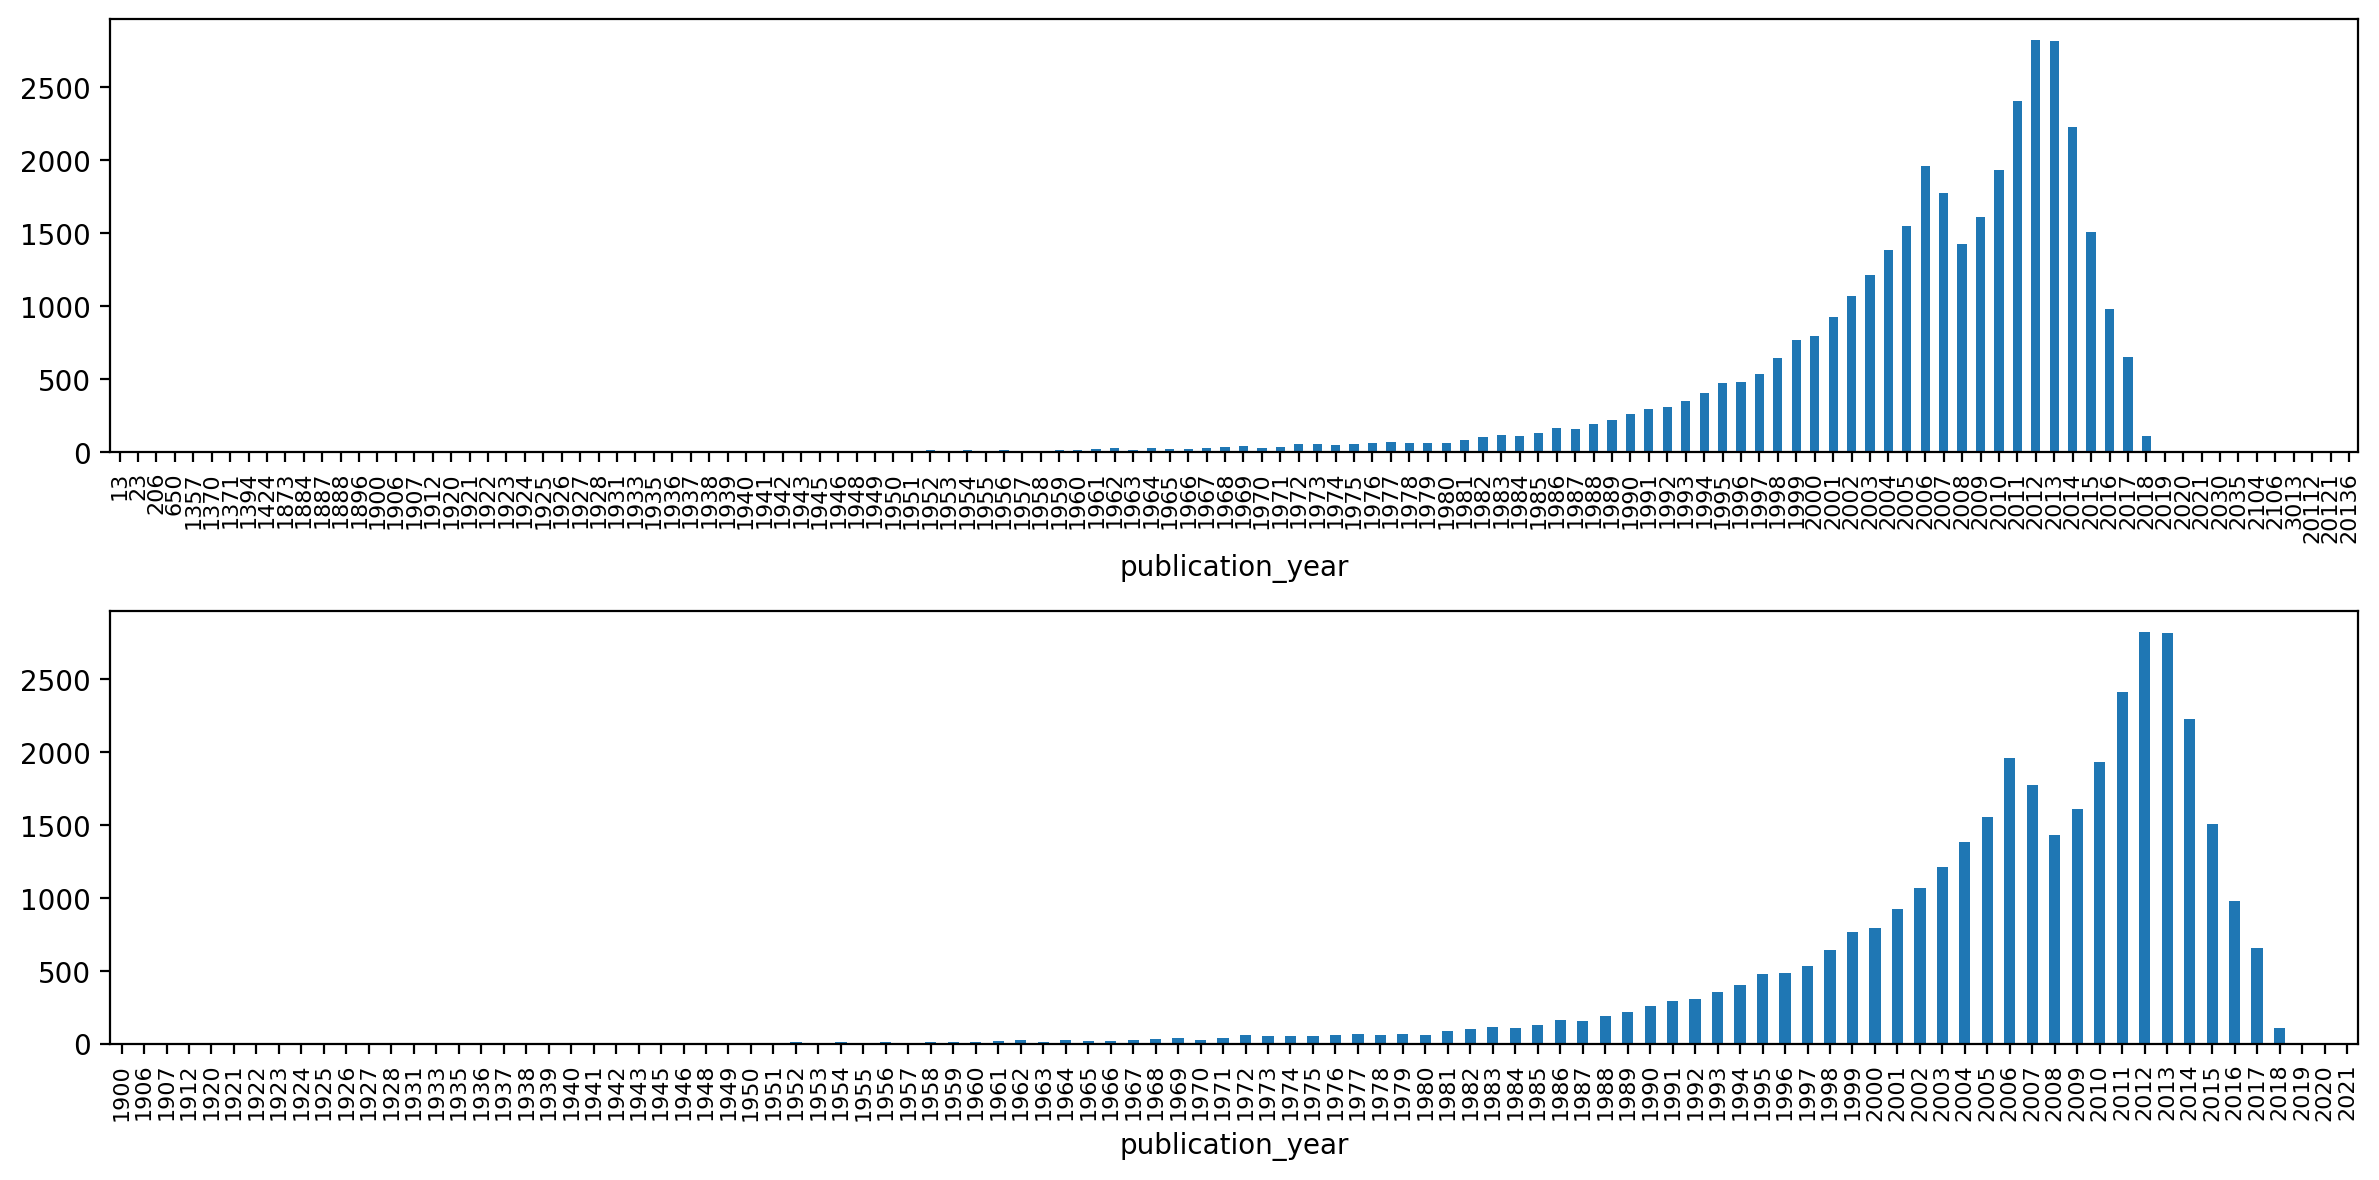

In [41]:
# распределение книг по годам публикации

fig, axs = plt.subplots(2, 1, figsize=(12, 6))

ax = axs[0]
books["publication_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.tick_params(axis='x', labelsize=8)

ax = axs[1]
books.query("publication_year >= 1900 and publication_year <= 2025")["publication_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.tick_params(axis='x', labelsize=8)

fig.tight_layout()

# События по месяцам

In [42]:
from pandas.tseries.offsets import MonthEnd

interactions["started_at_month"] = pd.to_datetime(interactions["started_at"]).dt.to_period('M').dt.to_timestamp().dt.date

In [43]:
interactions_by_month = interactions.groupby("started_at_month").agg(events=("started_at", "count"), users=("user_id", "nunique")).reset_index()

In [44]:
interactions_by_month

,started_at_month,events,users
0,2007-01-01,1993,1071
1,2007-02-01,201,135
2,2007-03-01,222,152
3,2007-04-01,201,135
4,2007-05-01,204,138
...,...,...,...
127,2017-08-01,202129,93040
128,2017-09-01,172187,82694
129,2017-10-01,108107,58076
130,2017-11-01,565,475


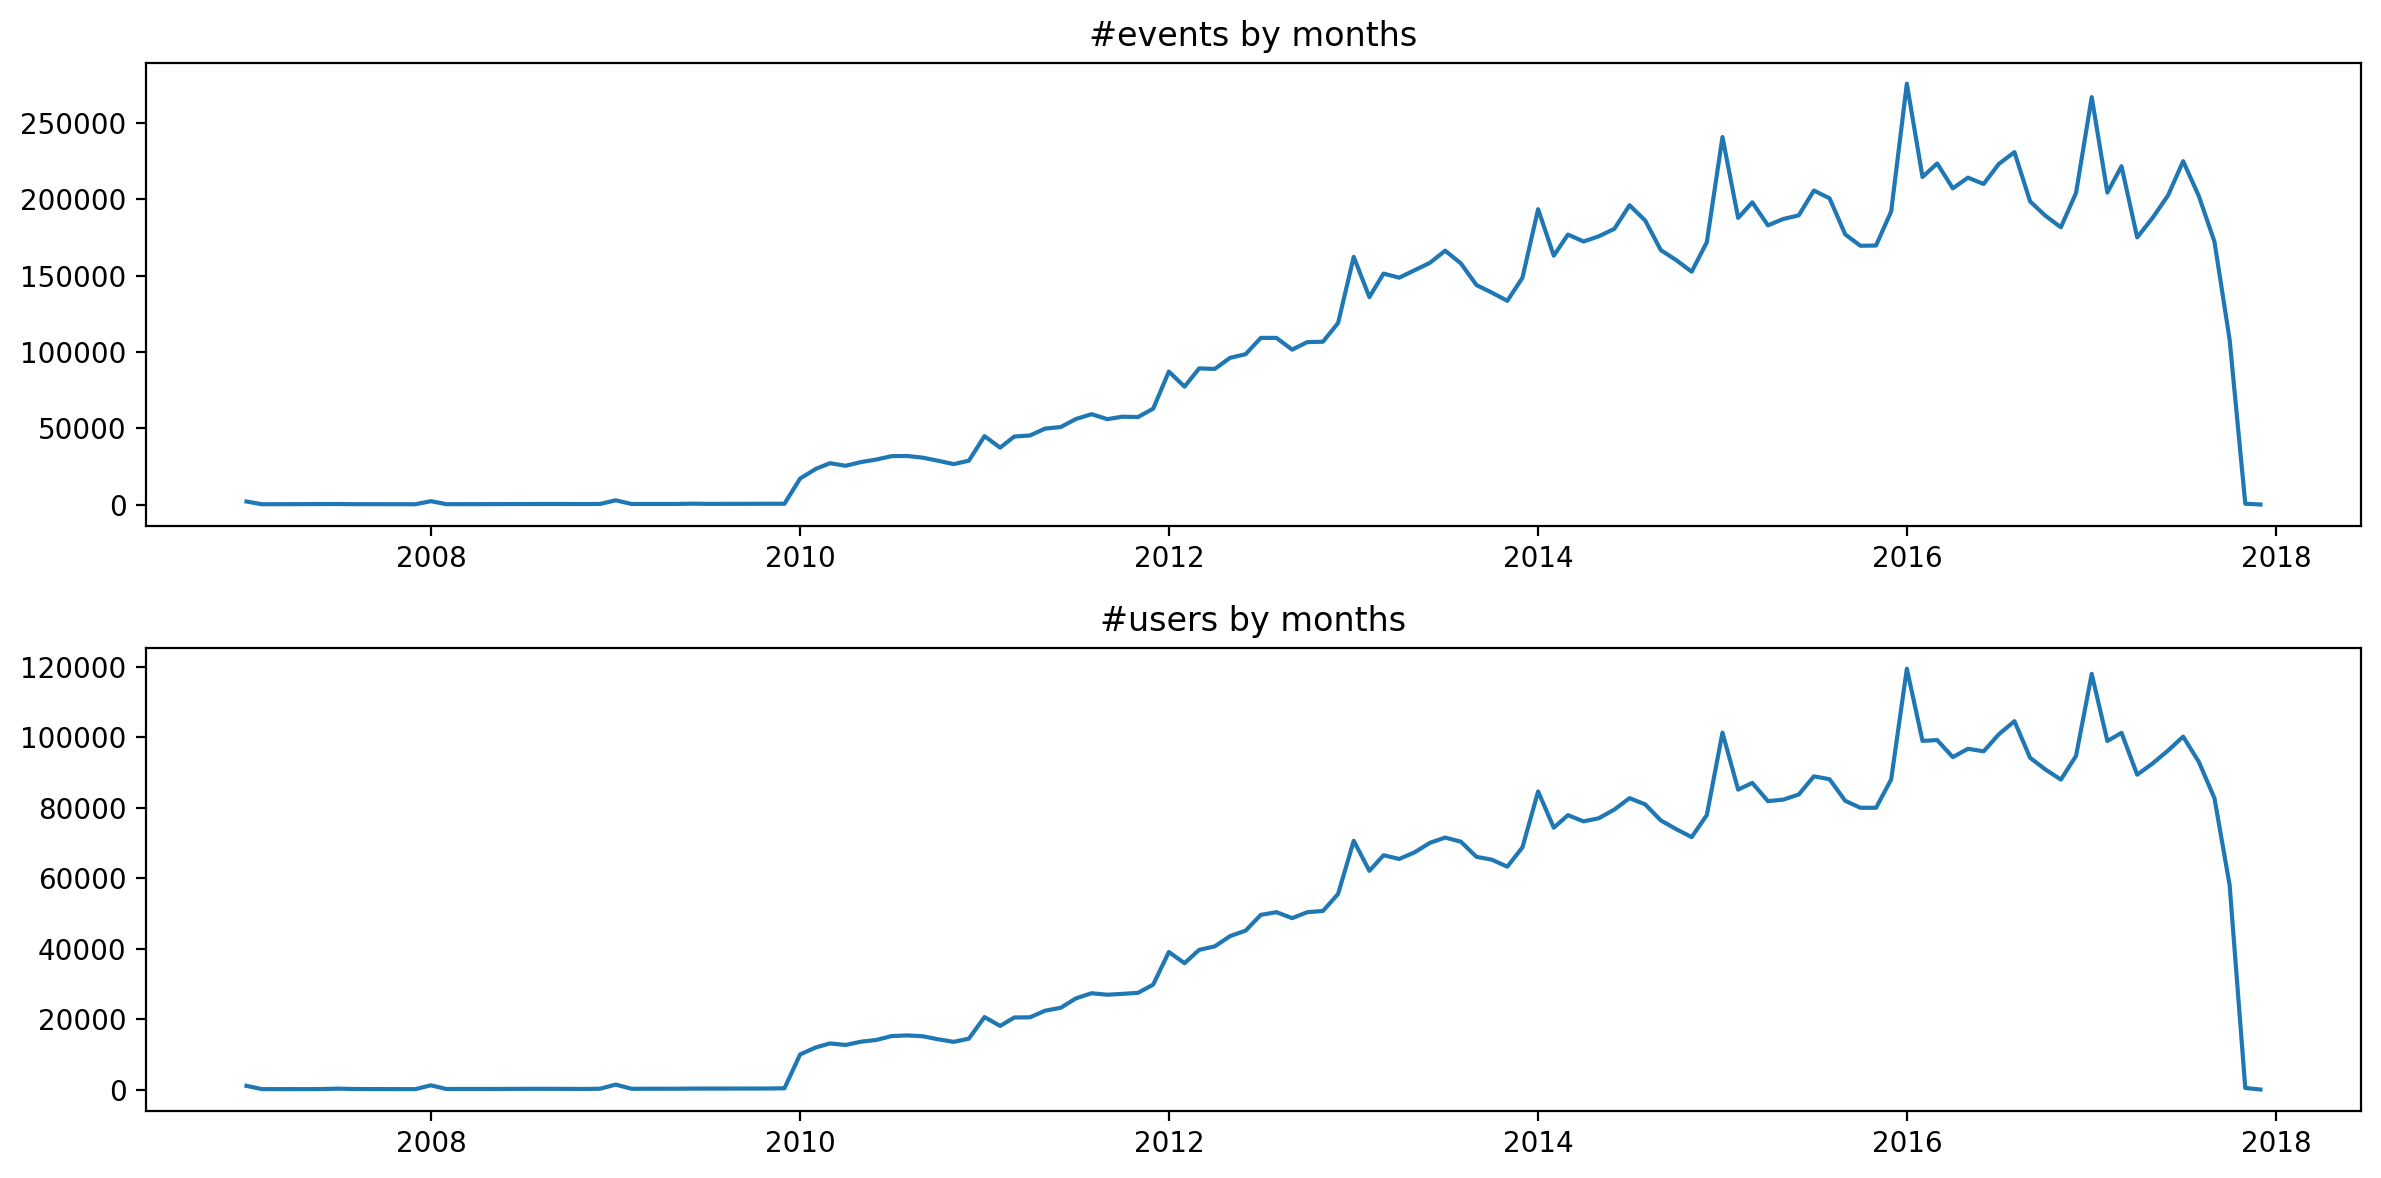

In [45]:
# распределение взаимодействий по годам

fig, axs = plt.subplots(2, 1, figsize=(12, 6))

ax = axs[0]
ax.plot(interactions_by_month["started_at_month"], interactions_by_month["events"])
# ax.tick_params(axis='x', labelsize=8)
ax.set_title("#events by months")

ax = axs[1]
ax.plot(interactions_by_month["started_at_month"], interactions_by_month["users"])
# ax.tick_params(axis='x', labelsize=8)
ax.set_title("#users by months")

fig.tight_layout()

# Преобработка

Примем новые именования:
- books -> items (более обобщённое название)
- interactions -> events (несколько короче, удобнее в коде)

In [46]:
items = books.copy()
events = interactions.copy()
events_initial_cnt = interactions.shape[0]


In [47]:
del books
del interactions

In [48]:
# оставим события только до ноября 2017
event_cutoff_date = pd.Timestamp("2017-11-01")
events["started_at"] = pd.to_datetime(events["started_at"], errors="coerce")
events["read_at"] = pd.to_datetime(events["read_at"], errors="coerce")
events = events[(events["started_at"] < event_cutoff_date) & (events["read_at"] < event_cutoff_date)].copy()


# Ваш код здесь


In [49]:
# удалим события без рейтинга и оставим только прочитанные
events = events[events["rating"].notna() & (events["rating"] > 0)].copy()
events = events[events["is_read"] == True].copy()

# оставим пользователей, у которых >=2 прочитанных книг
user_reads = events.groupby("user_id").size()
valid_users = user_reads[user_reads >= 2].index
events = events[events["user_id"].isin(valid_users)].copy()

# переименуем сущности и идентификатор книги
items = items.rename(columns={"book_id": "item_id"})
events = events.rename(columns={"book_id": "item_id"})

# перекодируем user_id: сортировка + нумерация с 1_000_000
unique_users = sorted(events["user_id"].astype(str).unique())
user2id = {u: 1_000_000 + i for i, u in enumerate(unique_users)}
events["user_id"] = events["user_id"].map(user2id).astype("int64")


# Сохранение результатов

In [50]:
items.to_parquet("items.parquet", index=False)

In [51]:
events.to_parquet("events.parquet", index=False)

In [52]:
events_final_cnt = events.shape[0]
events_share = events_final_cnt / events_initial_cnt
print(events_initial_cnt, events_final_cnt, events_share)


12890434 11751086 0.9116129061286843


In [53]:
train_test_global_time_split_date = pd.Timestamp("2017-08-01")

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx].copy()
events_test = events[~train_test_global_time_split_idx].copy()

users_train = events_train["user_id"].drop_duplicates()
users_test = events_test["user_id"].drop_duplicates()
common_users = set(users_train).intersection(set(users_test))

print(len(users_train), len(users_test), len(common_users))


428220 123223 120858


In [54]:
# "холодные" пользователи: есть в test, нет в train
cold_users = set(users_test) - set(users_train)

print(len(cold_users))

2365


## Задание 4 из 6
Построим топ-100 популярных книг для холодного старта.


In [55]:
from sklearn.preprocessing import MinMaxScaler

top_pop_start_date = pd.Timestamp("2015-01-01")

item_popularity = events_train \
    .query("started_at >= @top_pop_start_date") \
    .groupby(["item_id"]).agg(users=("user_id", "nunique"), avg_rating=("rating", "mean")).reset_index()

# нормализация пользователей и среднего рейтинга, требуется для их приведения к одному масштабу
scaler = MinMaxScaler()
item_popularity[["users_norm", "avg_rating_norm"]] = scaler.fit_transform(
    item_popularity[["users", "avg_rating"]]
)

# вычисляем popularity_score, как скор популярности со штрафом за низкий рейтинг
item_popularity["popularity_score"] = (
    item_popularity["users_norm"] * item_popularity["avg_rating_norm"]
)

# сортируем по убыванию popularity_score
item_popularity = item_popularity.sort_values("popularity_score", ascending=False)

# выбираем первые 100 айтемов со средней оценкой avg_rating не меньше 4
top_k_pop_items = item_popularity.query("avg_rating >= 4").head(100)

top_k_pop_items.head()


,item_id,users,avg_rating,users_norm,avg_rating_norm,popularity_score
32387,18007564,20207,4.321275,0.496596,0.830319,0.412333
32623,18143977,19462,4.290669,0.478287,0.822667,0.393471
2,3,15139,4.706057,0.372042,0.926514,0.344702
30695,16096824,16770,4.301014,0.412126,0.825253,0.340108
1916,15881,13043,4.632447,0.320529,0.908112,0.291076


In [56]:
# сколько пользователей оценило книгу на первом месте
int(top_k_pop_items.iloc[0]["users"])


20207

## Задание 5 из 6
Сопоставим события холодных пользователей с top-100 рекомендациями и посчитаем долю совпадений.


In [ ]:
cold_users_events_with_recs = (
    events_test[events_test["user_id"].isin(cold_users)]
    .merge(top_k_pop_items[["item_id", "avg_rating"]], on="item_id", how="left")
)

cold_user_items_no_avg_rating_idx = cold_users_events_with_recs["avg_rating"].isnull()
cold_user_recs = cold_users_events_with_recs[~cold_user_items_no_avg_rating_idx][
    ["user_id", "item_id", "rating", "avg_rating"]
]

print(len(cold_users_events_with_recs), len(cold_user_recs))


In [ ]:
cold_match_share = (~cold_user_items_no_avg_rating_idx).mean()
print(cold_match_share)
print(round(cold_match_share, 2))


## Задание 6 из 6
Посчитаем RMSE и MAE для рекомендаций холодного старта.


In [ ]:
# посчитаем метрики рекомендаций
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = mean_squared_error(cold_user_recs["rating"], cold_user_recs["avg_rating"], squared=False)
mae = mean_absolute_error(cold_user_recs["rating"], cold_user_recs["avg_rating"])
print(round(rmse, 2), round(mae, 2))
